In [1]:
import pyvista as pv
import stellarvista as sv

## Inspect DAGMC model and unstructured mesh

/home/sampasmann/miniconda3/envs/stellarvista/lib/python3.12/site-packages/pydagmc/dagnav.py:343: UserWarning: Assigned geom_dimension=4 to group 'picked'.
  warn(f"Assigned geom_dimension={self._geom_dimension} to {identifier}.")
/home/sampasmann/miniconda3/envs/stellarvista/lib/python3.12/site-packages/pydagmc/dagnav.py:343: UserWarning: Assigned geom_dimension=4 to group 'mat:steel'.
  warn(f"Assigned geom_dimension={self._geom_dimension} to {identifier}.")
/home/sampasmann/miniconda3/envs/stellarvista/lib/python3.12/site-packages/pydagmc/dagnav.py:343: UserWarning: Assigned geom_dimension=4 to group 'mat:air'.
  warn(f"Assigned geom_dimension={self._geom_dimension} to {identifier}.")
/home/sampasmann/miniconda3/envs/stellarvista/lib/python3.12/site-packages/pydagmc/dagnav.py:343: UserWarning: Assigned geom_dimension=4 to group 'mat:graveyard'.
  warn(f"Assigned geom_dimension={self._geom_dimension} to {identifier}.")


MultiBlock (0x7fbe601e1960)
  N Blocks:   8
  X Bounds:   -2.310e+02, 2.310e+02
  Y Bounds:   -5.034e+01, 2.401e+02
  Z Bounds:   -2.244e+01, 1.756e+02

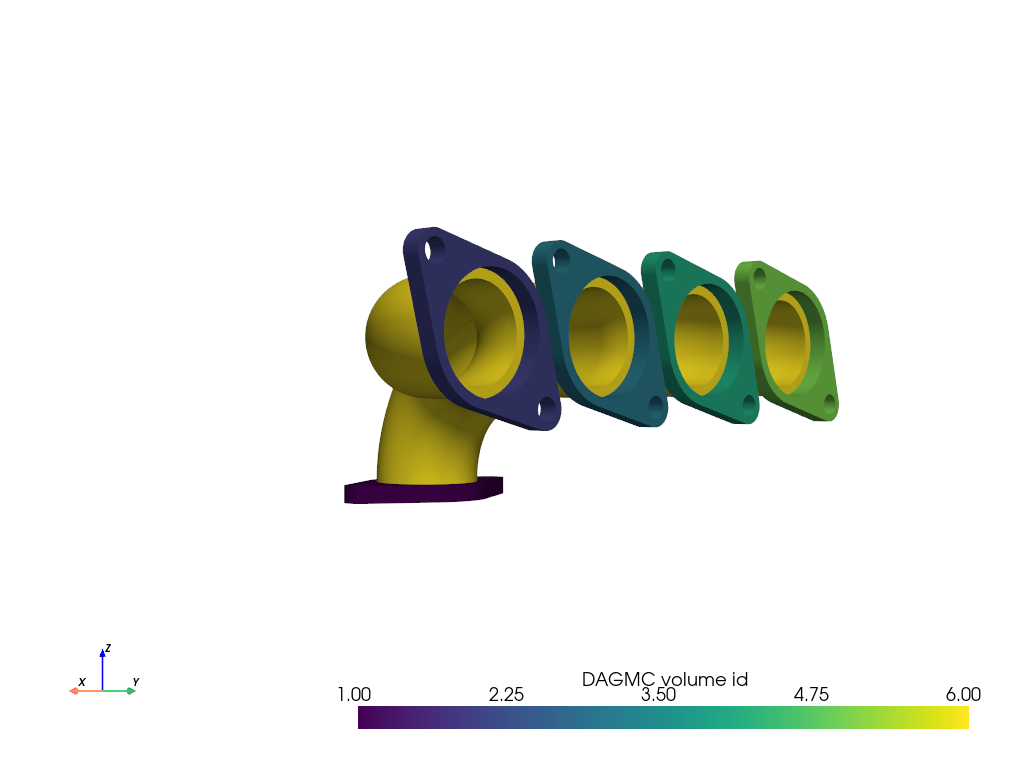

In [2]:
model = sv.import_dagmc('./model_manifold/dagmc.h5m')
display(model)
model[:-2].plot(jupyter_backend='static', cpos=[1,1,0])

Unstructred meshes stored in h5m files can be read natively by pyvista

UnstructuredGrid (0x7fbe26e371c0)
  N Cells:    84822
  N Points:   18902
  X Bounds:   -1.647e+02, 1.647e+02
  Y Bounds:   -3.628e+01, 1.800e+02
  Z Bounds:   -1.000e+01, 1.257e+02
  N Arrays:   1

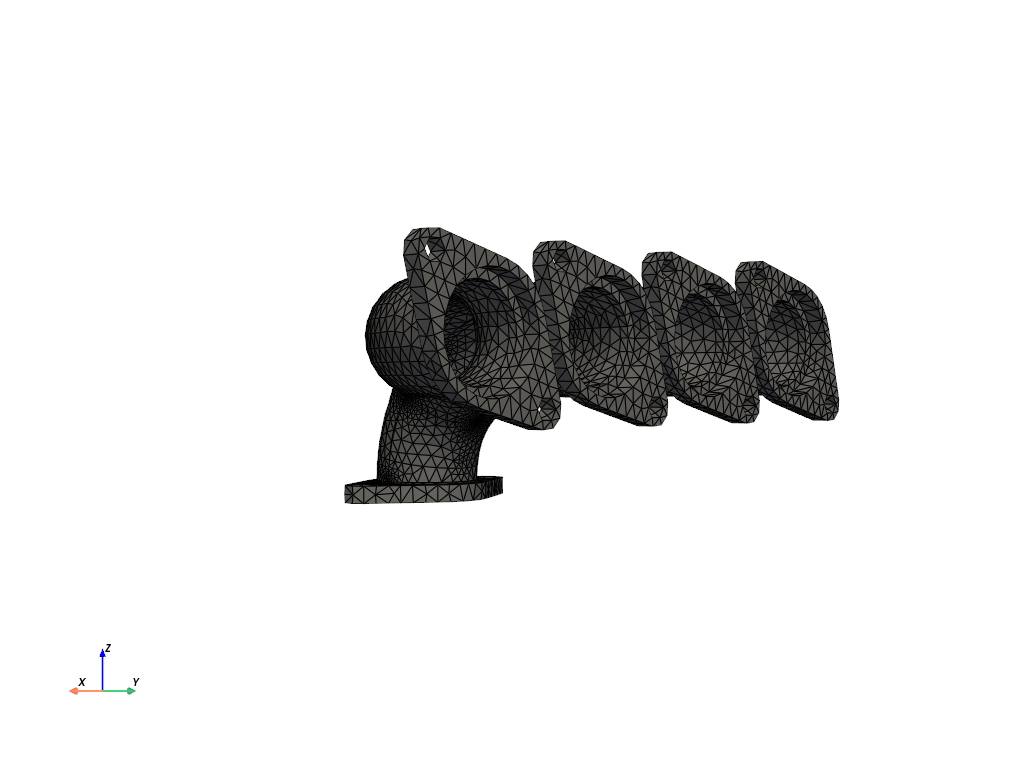

In [3]:
mesh = pv.read('./model_manifold/unstructured_mesh.h5m')
display(mesh)
mesh.plot(show_edges=True, color='gray', jupyter_backend='static', cpos=[1,1,0])

/home/sampasmann/miniconda3/envs/stellarvista/lib/python3.12/site-packages/openmc/tallies.py:1359: RuntimeWarning: invalid value encountered in divide
  data = self.std_dev[indices] / self.mean[indices]


UnstructuredGrid (0x7fbe09b41ea0)
  N Cells:    84822
  N Points:   18902
  X Bounds:   -1.647e+02, 1.647e+02
  Y Bounds:   -3.628e+01, 1.800e+02
  Z Bounds:   -1.000e+01, 1.257e+02
  N Arrays:   6

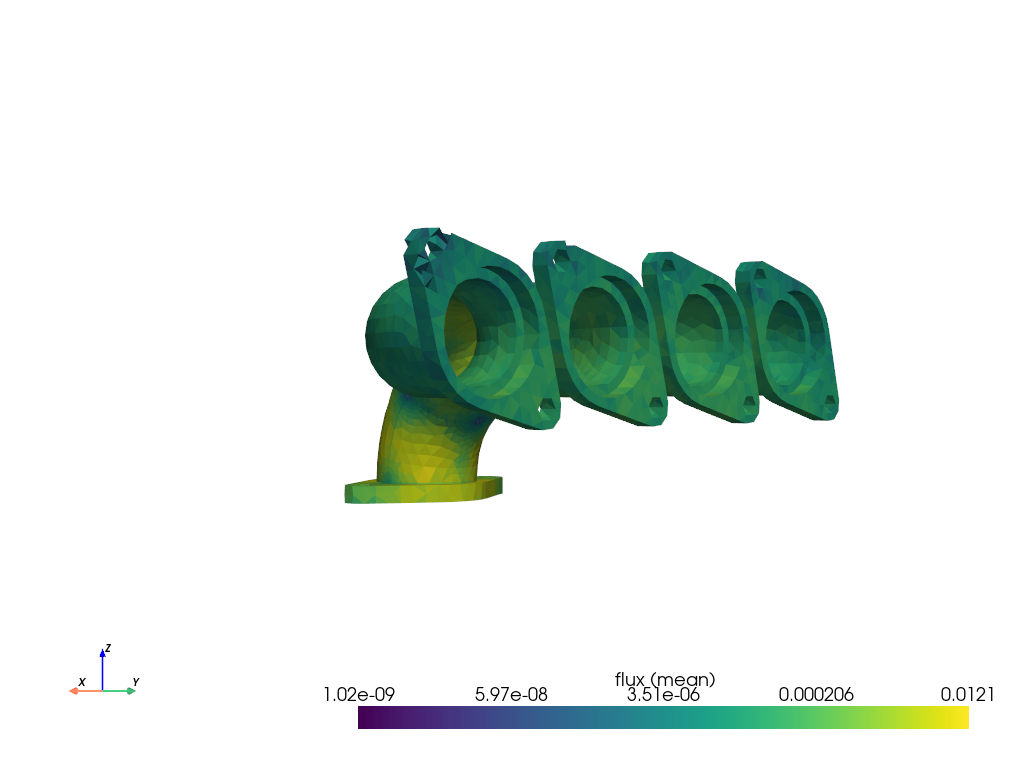

In [4]:
mesh = sv.convert_unstructured_mesh_tally('./model_manifold/statepoint.200.h5', 'flux')
display(mesh)
mesh.set_active_scalars('flux (mean)')
mesh.threshold([1e-9, 0.99]).plot(log_scale=True, jupyter_backend='static', cpos=[1,1,0])

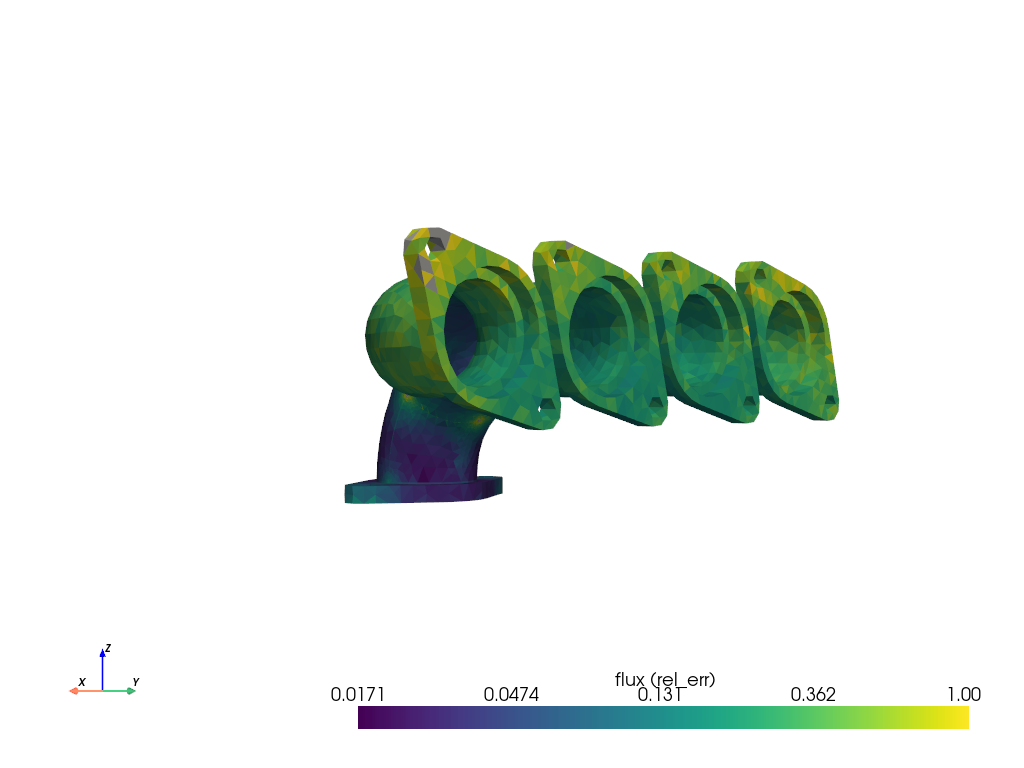

In [5]:
mesh.set_active_scalars('flux (rel_err)')
mesh.plot(log_scale=True, jupyter_backend='static', cpos=[1,1,0])